# Portfolio loss and importance sampling.

Let $V(S)$ be the value of a portfolio value consisting of
financial instruments based on $m$ market prices $S \in \mathbb{R}^m$. The goal of this project is
to use Monte Carlo to estimate the portfolio loss $L$ over short time periods $\Delta T$. Here, it
is common to use the delta-gamma representation, where the loss is written as
$$
L:=\delta^{\top} \Delta S+(\Delta S)^{\top} \Gamma \Delta S,
$$
where $\delta \in \mathbb{R}^m, \Gamma \in \mathbb{R}^{m \times m}$ and $\Delta S \sim N\left(0,
\Sigma_S\right)$ for some covariance matrix $\Sigma_S$. Sometimes, it is helpful to consider the
linear approximation
$$
Q:=\delta^{\top} \Delta S .
$$
First, assume that $m=1, \delta=2, \Gamma=\Sigma_S=1$, and $x=10$. 
Please always justify your answer.

In [1]:
# setup (only needed once, this cell is hidden in export)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.stats import norm, ncx2

## Questions
 

 
> #### Exercise a)
> Write a program to estimate the exceedance probabilities $\mathbb{P}(L>x)$ by crude Monte Carlo simulation.

For a better comparison of our results, we first derive the analytical probability, for the simple case $m=1, \delta=2$ and $\Gamma=\Sigma_S=1$. 
Using these parameters we can write:
$$
\mathbb{P}(L > x) = \mathbb{P}(2Z + Z^2 >x) \quad Z \sim N(0,1)
$$
Completing the square we get $2Z + Z^2 =(Z+1)^2-1= Y - 1$ where $Y \sim X^2_{nc}(\nu = 1, \lambda = 1)$, and where $X^2_{nc}(\nu, \lambda)$ denotes a non-central chi-square distribution with $\nu$ degrees of freedom and non-centrality parameter $\lambda$. In particular the analytical probability is can be calulated by:
$$
\mathbb{P}(L > x) = 1 - \mathbb{P}(Y -1 \le x ) = 1 - \mathbb{P}(Y \le x +1)
$$
This is determined to be

In [2]:
x = 10.0
analytical_prop = 1-ncx2.cdf(x+1, df=1, nc=1)
print(f"Analytical probability P(L > {x}): {analytical_prop:.6f}")

Analytical probability P(L > 10.0): 0.010270


We now implement a crude Monte Carlo simulation, of this probability. We first define:

In [3]:
np.random.seed(2)  # for reproducibility
# assumptions
m = 1
delta = 2.0
gamma = 1.0
sigma = np.array([[1.0]])  # covariance matrix


def loss(m, delta, delta_S, gamma):
    """ Compute the loss L given delta, gamma, sigma and delta_S, note that all parameters shold be of dimension m."""
    if m == 1:
        Q = delta*delta_S
        L = Q + (delta_S * gamma) * delta_S
    else:
        Q = delta_S@delta
        L = Q + np.sum((delta_S @ gamma) * delta_S, axis=1)
    return L

Crude Monte Carlo is then done by finding $N$ realizations of $\Delta S \sim N(0,1)$. For each realization we then determine the *empirical* loss $\tilde L$ and weather or not $\tilde L < x$. In particular the Law of large numbers then gives that
$$
\frac{\mathbf{1}_{ L_1 < x} + \ldots +  \mathbf{1}_{ L_N < x} }{N} \underset{N \to \infty}{\longrightarrow}\mathbb{E}[\mathbf{1}_{ L_1 < x}] = \mathbb{P}(L_1 < x) = 0.010270
$$
In other words, crude Monte Carlo will converge towards the analytical probability when we increase our sample size parameter $N$. 

For $N=10^6$ we find:

In [4]:
N = 10**6  # number of simulations


def crude_monte_carlo(N, m, delta, gamma, sigma, x, loss_function):
    """ Crude Monte Carlo simulation of the probability P(L > x), note that all parameters shold be of dimension m."""

    delta_S = np.random.multivariate_normal(np.zeros(m), sigma, size=N)
    L = loss_function(m, delta, delta_S, gamma)
    return np.mean(L > x), L


P_crude, L = crude_monte_carlo(N, m, delta, gamma, sigma, x, loss)
print(f"Crude Monte Carlo estimate of P(L > {x}): {P_crude:.6f}")
print(f"Difference to analytical: {abs(P_crude - analytical_prop):.6f}")

Crude Monte Carlo estimate of P(L > 10.0): 0.010188
Difference to analytical: 0.000082


Which is already a quite small deviation, however for smaller $N$ we find:

In [5]:
N = 100
P_crude_small, L_small = crude_monte_carlo(N, m, delta, gamma, sigma, x, loss)
print(
    f"Crude Monte Carlo estimate of P(L > {x}) with N={N}: {P_crude_small:.6f}")
print(f"Difference to analytical: {abs(P_crude_small - analytical_prop):.6f}")

Crude Monte Carlo estimate of P(L > 10.0) with N=100: 0.000000
Difference to analytical: 0.010270


By the above, it is clear that our crude monte carlo estimate very much depends on the value of $N$. 

> #### Exercise b)
>  Use control variables method to reduce the variance of the estimator from part (a).  Discuss several possibilities and argue for your final choice.  Would you recommend to use these methods given potential longer compute time?

In our Monte Carlo simulation, we want to determine $\mathbb{P}(L > x) = \mathbb{E}[\mathbf{1}_{L > x}] =: \ell$. We know that this can be done naively by the crude Monte Carlo utilizing the Law of Large numbers. However, if we want a high precision of the estimate, we might need a very high sample size $N$. Another way to determine the quality of our estimates, compared to the absoulte difference in numerical value above, is the mean-squared error. For a given set of samples $Y_1,\ldots,Y_n$ from the crude Monte Carlo  we have:
$$
\mathbb{E}\left[\left(\frac{(Y_1 + \ldots + Y_n)}{N} - \mathbb{E}[Y_1]\right)^2\right] = \mathbb{V}\left[\frac{(Y_1 + \ldots + Y_n)}{N}\right] = \frac{1}{N}\mathbb{V}[Y_1].
$$
The control variables method is one way to guarentee a variance reduction and thus increase the quality of our estimate of $\ell$, at least by the above measure of quality. The main idea is that apart from sampling variables of the form $Y = \mathbf{1}_{L < x}$ as in the crude Monte Carlo, we also calculate $Z$, where $\mathbb{E}[Z]$ is known, and where $Y$ and $Z$ are positively correlated. We then use $\hat Y = Y - (Z - \mathbb{E}[Z])$ as our new variable for the Law of large numbers, indeed:
$$
\mathbb{E}[\hat Y] = \mathbb{E}[Y] - 0 = \ell
$$
 In particular, we have shown in the lectures, that for the class of estimators given by
$$
\hat\ell := \frac{1}{N} \sum_{i \leq N}\left[Y-\beta\left(Z_i-\ell_Z\right)\right]
$$
there exists an optimal $\beta$ given by
$$
\beta_{\mathrm{opt}}=\frac{\mathrm{Cov}[Y, Z]}{\mathbb{V}(Z)}
$$
and the minimum value of the variance is
$$
\frac{1}{N} \mathbb{V}(Y)\left(1-\mathrm{Corr}[Y, Z]^2\right)
$$
By the above, the a variance reduction is then guarenteed since $Y$ and $Z$ was assumed to be positivly correlated.

To implement this method we will use the proposed estimator $Q$ stated in the project description, and consider $\mathbf{1}_{Q > (x/2)}$. In particular, for the case at hand, we have $\mathbb{E}[\mathbf{1}_{Q > y}] = \mathbb{P}[\delta\Delta S \ge y] = 1-\phi(y/\delta)$, since $\Delta S\sim N(0,1)$.

In [6]:
def Q_estimator(Z, y, delta, m):
    if m == 1:
        Q = delta*Z
        mean = 1.0-norm.cdf(y/delta)
    else:
        Q = Z@delta
        mean = np.mean(Q > y)  # approximate mean
    return Q > y, mean

We can then implement Control variance for this estimator

In [7]:
N = 10**6


def control_variance_monte_carlo(N, m, delta, sigma, x, control_variance_estimator, y):
    """ Control Variance monte carlo of P(L>x), note that all parameters shold be of dimension m."""

    Z = np.random.multivariate_normal(np.zeros(m), sigma, N)
    Y = loss(m, delta, Z, gamma) > x
    H, l_H = control_variance_estimator(Z, y, delta, m)

    model = LinearRegression()
    beta = model.fit(H.reshape(-1, 1), Y).coef_[0]

    Y_hat = Y - beta*(H - l_H)

    return np.mean(Y_hat), Y, Y_hat

Using the function above one could try the control variate $\mathbf{1}_{Q > x/2}$ to get the following variance reduction:

In [8]:
P_cv_Q, Y_Q, Y_hat_Q = control_variance_monte_carlo(
    N, m, delta, sigma, x, Q_estimator, x/2)
var_r_cv_Q = np.var(Y_Q)/np.var(Y_hat_Q)
print(
    f"Control Variance using Q in Monte Carlo estimate of P(L > {x}): {P_cv_Q:.6f}")
print(f"Variance reduction: {var_r_cv_Q:.2f} times")

Control Variance using Q in Monte Carlo estimate of P(L > 10.0): 0.010277
Variance reduction: 2.46 times


An obvious question is how much variance reduction we could obtain by variying the $y$ parameter in the control variate $\mathbf{1}_{Q > y}$, this is the content of the code below:

In [9]:
# find the best y to use in the control variate
Y = np.linspace(0, x, 100)
P_cv_list = []
variance_reduction_list = []
for y in Y:
    P_cv, Y_samples, Y_hat = control_variance_monte_carlo(
        N, m, delta, sigma, x, Q_estimator, y)
    P_cv_list.append(P_cv)
    variance_reduction_list.append(np.var(Y_samples)/np.var(Y_hat))
P_cv_list = np.array(P_cv_list)
variance_reduction_list = np.array(variance_reduction_list)
best_y = Y[np.argmax(variance_reduction_list)]
print(f"Best y: {best_y:.2f} with variance reduction of {np.max(variance_reduction_list):.2f} times")

Best y: 4.65 with variance reduction of 55.86 times


In particular, our guess of $x/2 = 5$ is not that far from the best fitted $y$ to the sample. We could also do a control variable on the quadratic part of $L$, for this estimator we have:
$$
M=(\Delta S)^{\top} \Gamma \Delta S, \quad \mathbb{E}[\mathbf{1}_{M > y}] = \mathbb{P}((\Delta S)^2 > y) = 1-(\phi(\sqrt{y}) - \phi(-\sqrt{y})) = 1- (\phi(\sqrt{y})-(1-\phi(\sqrt{y}))) = 2\phi(\sqrt{y})
$$

In [10]:
def M_estimator(Z, y, delta, m):
    if m == 1:
        M = (Z * gamma) * Z
        mean = 2*(1.0-norm.cdf(np.sqrt(y)))
    else:
        M = np.sum((Z @ gamma) * Z, axis=1)
        mean = np.mean(M > y)  # approximate mean
    return M > y, mean

Using again the guess of $y=x/2$ we get:

In [11]:
P_cv_M, Y_M, Y_hat_M = control_variance_monte_carlo(
    N, m, delta, sigma, x, M_estimator, x/2)
var_r_cv_M = np.var(Y_M)/np.var(Y_hat_M)
print(
    f"Control Variance using M in Monte Carlo estimate of P(L > {x}): {P_cv_M:.6f}")
print(
    f"Variance reduction: {var_r_cv_M:.2f} times")

Control Variance using M in Monte Carlo estimate of P(L > 10.0): 0.010439
Variance reduction: 1.68 times


And again we can check our guess by simply doing a scan over different $y$ values:

In [12]:
Y = np.linspace(0, x, 100)
P_cv_list = []
variance_reduction_list = []
for y in Y:
    P_cv, Y_samples, Y_hat = control_variance_monte_carlo(
        N, m, delta, sigma, x, M_estimator, y)
    P_cv_list.append(P_cv)
    variance_reduction_list.append(np.var(Y_samples)/np.var(Y_hat))
P_cv_list = np.array(P_cv_list)
variance_reduction_list = np.array(variance_reduction_list)
best_y = Y[np.argmax(variance_reduction_list)]
print(f"Best y: {best_y:.2f} with variance reduction of {np.max(variance_reduction_list):.2f} times")

Best y: 5.35 with variance reduction of 1.97 times


Which again is shows that our guess of $x/2 = 5$ is not that far from the best fitted $y$ to the sample. The final control vairatate method we can look at is when we use both control variables, for simplicity we will simply ues again $y_1=y_2 =x/2$:

In [13]:
def control_variance_both_estimators(N, m, delta, sigma, gamma, x, y1, y2):
    """ Control Variance monte carlo of P(L>x), note that all parameters shold be of dimension m."""
    Z = np.random.multivariate_normal(np.zeros(m), sigma, N)
    Y = loss(m, delta, Z, gamma) > x
    H1, l_H1 = Q_estimator(Z, y1, delta, m)
    H2, l_H2 = M_estimator(Z, y2, delta, m)

    H = np.column_stack((H1, H2))

    model = LinearRegression(fit_intercept=False)
    H_centered = H - np.array([l_H1, l_H2])
    beta = model.fit(H_centered, Y).coef_
    if m == 1:
        beta = beta[0]
        Y_hat = Y - beta[0]*(H1 - l_H1) - beta[1]*(H2 - l_H2)
    else:
        Y_hat = Y - H_centered@beta

    return np.mean(Y_hat), Y, Y_hat


P_cv_both, Y, Y_hat_both = control_variance_both_estimators(
    N, m, delta, sigma, gamma, x, x/2.0, x/2.0)
var_r_cv_both = np.var(Y)/np.var(Y_hat_both)
print(
    f"Control Variance using Q and M in Monte Carlo estimate of P(L > {x}): {P_cv_both:.6f}")
print(f"Variance reduction: {var_r_cv_both:.2f} times")

Control Variance using Q and M in Monte Carlo estimate of P(L > 10.0): 0.010355
Variance reduction: 3.16 times


> #### Exercise c)
> Design an importance-sampling method to reduce the variance of the estimator from part (a). Again, discuss several options and argue for your final choice. Again, discuss the trade-off between additional compute time and variance reduction.

In importance sampling we want to find another density, which will give more information from each simulated value. In other words we want to find a density $g$, where the event $L > 10$ is more likely.

Let's start by computing the points $x$, fulfilling $L>10$:
$$L=x^2 + 2x > 10$$
$$\Leftrightarrow x^2 + 2x + 1 > 11$$
$$\Leftrightarrow x+1 > \sqrt{11}, \quad  x+1 < - \sqrt{11}$$
$$\Leftrightarrow x_1 > 2.3166, \quad x_2 < -4.3166$$
This means, that
$$\mathbb{P} (L > 10) = \mathbb{P} ((\Delta S)^2 + 2 \Delta S > 10) = \mathbb{P} (\Delta S < -4.3166) + \mathbb{P} (\Delta S > 2.3166)$$

Now it is worth noticing that since $\Delta S \sim N(0,1)$, then
$$\mathbb{P} (\Delta S > 2.3166) = 1 - \Phi (2.3166) = 0.01022$$
$$\mathbb{P} (\Delta S < -4.3166) = \Phi (-4.3166) = 0.0000085$$
Which means that almost all of the contribution to $\mathbb{P} (L > 10)$ comes from $\Delta S > 2.3166$, i.e. the upper tail. 
Therefore, it wouldn't make much sense to do Importance Sampling (exponential tiliting), where we set $x = -4.3166$.
Now it is left to either do Importance Sampling (exponential tilting) with respect to $x = 2.3166$ or a mixture of the two. But, since the contribution of $(\Delta S < -4.3166)$ is that minor, a mixture would probably only result in more wasted samples.

Thus, we will only do importance sampling where we shift the distribution of $\Delta S$ to collect the effect of $\Delta S > 2.3166$.

This we will do by exponential tilting.

Therefore, let $x = \sqrt{11} - 1$ and we compute the optimal $\theta$ as the one fulfilling
$$\kappa^{\prime} (\theta) = x$$
where $\kappa^{\prime} (\theta)$ is given as the following, as $\Delta S \sim N(0, 1)$
$$\kappa^{\prime} (\theta) = \mu + \sigma^2 \cdot \theta = \theta = \mathbb{E}_{\theta} [\Delta S]$$
Solving for $\theta$ gives
$$\theta = x$$

In the following we will use this $\kappa (\theta)$ (again as $\Delta S \sim N(0,1)$):
$$\kappa(\theta) = \mu \cdot \theta + 0.5 \cdot \sigma^2 \cdot \theta^2 = 0 \cdot x + 0.5 \cdot 1^2 \cdot x^2 = 0.5 \theta^2 $$
And weights:
$$e^{- \theta \cdot \Delta S + \kappa (\theta)}$$

In [14]:

N = 10**6
mu = np.array([[0]])
x_tilt = np.sqrt(11) - 1


def IS_simulation(N, mu, delta, gamma, sigma, x_tilt, x):
    # Actually theta = x, but to be able to use for all values of mu and sigma we write it like this
    theta = (x_tilt - mu) / (sigma**2)

    mu_tilted = mu + theta * (sigma**2)
    delta_S_tilted = np.random.normal(mu_tilted[0], sigma[0], N)

    L_tilted = delta_S_tilted**2 * gamma + delta * delta_S_tilted
    Z = L_tilted > x

    kappa = 0.5 * (theta**2)
    weights = np.exp(- theta * delta_S_tilted + kappa)

    weighted_Z = Z * weights

    return np.mean(weighted_Z), weighted_Z

In [15]:
# Exponential tilting with x=2.3166
P_IS, Y_IS = IS_simulation(
    N, mu, delta, gamma, sigma, x_tilt, x)
var_r_IS = np.var(L > x)/np.var(Y_IS)
print(
    f"IS Monte Carlo estimate of P(L > {x}): {P_IS:.6f}")
print(f"Variance reduction: {var_r_IS:.2f} times")

IS Monte Carlo estimate of P(L > 10.0): 0.010252
Variance reduction: 36.00 times


To emphasize that importance sampling where we shift $\Delta S$ to $N(-4.3166, 1)$ is not as effective, we consider the follwing:

In [16]:
x_tilt_2 = -np.sqrt(11) - 1
P_IS_neg, Y_IS_neg = IS_simulation(N, mu, delta, gamma, sigma, x_tilt_2, x)
# var_r_IS_neg = np.var(L > x)/np.var(Y_IS_neg)
print(
    f"IS (negative shift) Monte Carlo estimate of P(L > {x}): {P_IS_neg:.6f}")
# print(f"Variance reduction: {var_r_IS_neg:.2f} times")

IS (negative shift) Monte Carlo estimate of P(L > 10.0): 0.000008


Where it can clearly be seen, that we do not get an exceedance probability close to the theoretical exceedance probability.

> #### Exercise d)
>  Create and discuss visualizations for comparing (a), (b) and (c).

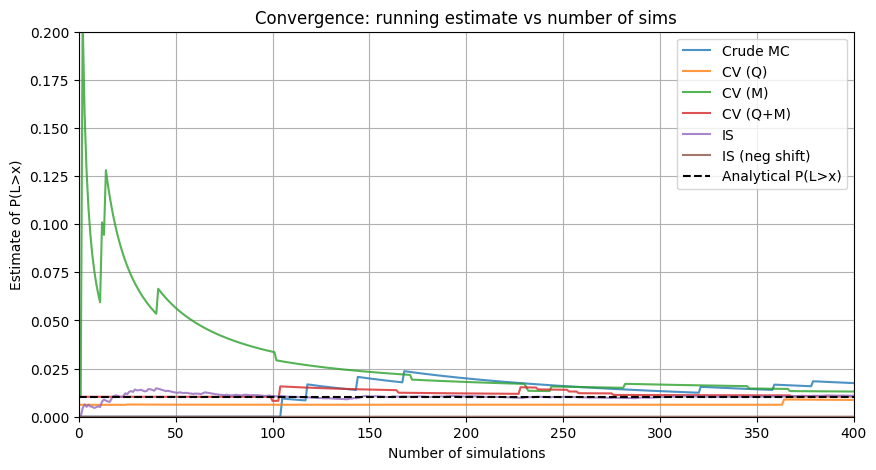

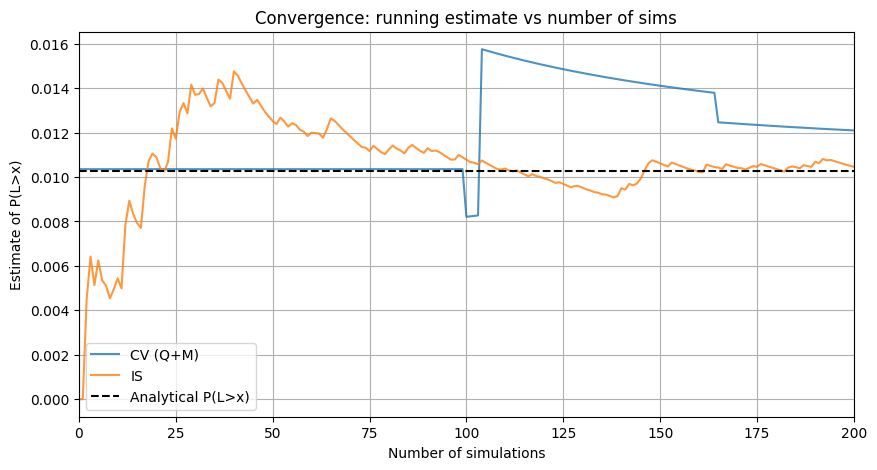

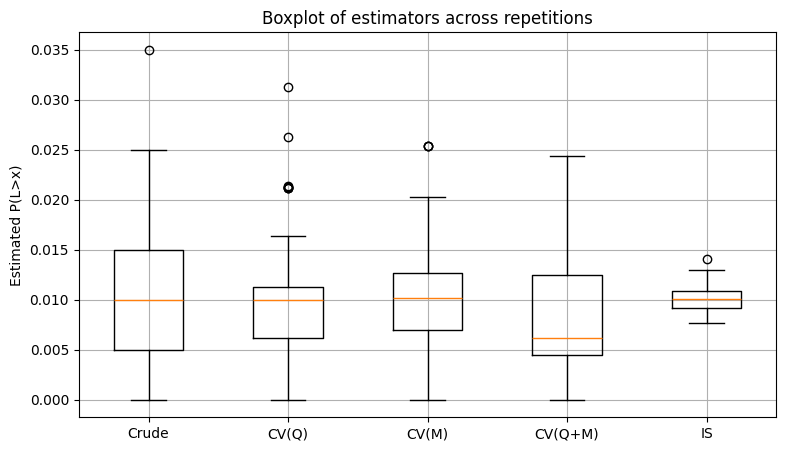

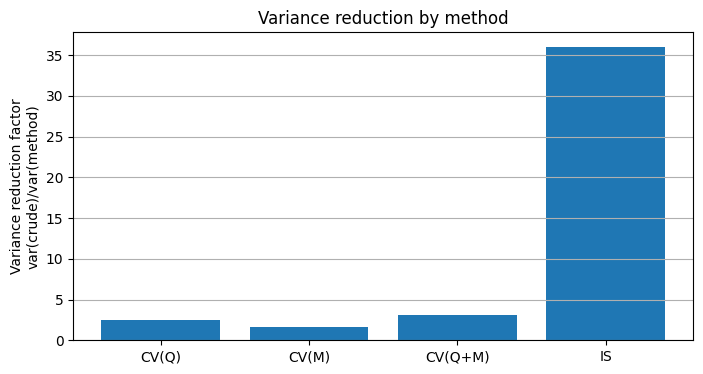

In [17]:
%matplotlib inline
#  Convergence of running estimator
def running_mean(arr):
    return np.cumsum(arr) / np.arange(1, len(arr)+1)


y_lim = 0.2
xlim = 400

plt.figure(figsize=(10, 5))
plt.plot(running_mean((L > x)), label='Crude MC', alpha=0.8)
plt.plot(running_mean(Y_hat_Q), label='CV (Q)', alpha=0.8)
plt.plot(running_mean (Y_hat_M), label='CV (M)', alpha=0.8)
plt.plot(running_mean(Y_hat_both), label='CV (Q+M)', alpha=0.8)
plt.plot(running_mean(Y_IS.T),label='IS', alpha=0.8)
plt.plot(running_mean(Y_IS_neg.T),label='IS (neg shift)', alpha=0.8)
plt.axhline(analytical_prop, color='black',
            linestyle='--', label='Analytical P(L>x)')
plt.xlabel('Number of simulations')
plt.ylabel('Estimate of P(L>x)')
plt.title('Convergence: running estimate vs number of sims')
plt.legend()
plt.grid(True)
plt.xlim(0, xlim)
plt.ylim(0, y_lim)
plt.show()


xlim = 200

#  Convergence of running estimator only CV(Q+M) and IS 
plt.figure(figsize=(10, 5))
plt.plot(running_mean(Y_hat_both), label='CV (Q+M)', alpha=0.8)
plt.plot(running_mean(Y_IS.T),label='IS', alpha=0.8)
plt.axhline(analytical_prop, color='black',
            linestyle='--', label='Analytical P(L>x)')
plt.xlabel('Number of simulations')
plt.ylabel('Estimate of P(L>x)')
plt.title('Convergence: running estimate vs number of sims')
plt.legend()
plt.grid(True)
plt.xlim(0, xlim)
plt.show()


#  Repeated runs 
reps = 100
N_per_run = 200
est_crude, est_cvQ, est_cvM, est_cvBoth, est_IS = (
    np.zeros(reps), np.zeros(reps), np.zeros(
        reps), np.zeros(reps), np.zeros(reps)
)
for i in range(reps):
    est_crude[i], L = crude_monte_carlo(
        N_per_run, m, delta, gamma, sigma, x, loss)
    est_cvQ[i], _, Y_hat_Q = control_variance_monte_carlo(
        N_per_run, m, delta, sigma, x, Q_estimator, x/2.0)
    est_cvM[i], _, Y_hat_M = control_variance_monte_carlo(
        N_per_run, m, delta,sigma, x, M_estimator, x/2.0)
    est_cvBoth[i], _, Y_hat_both = control_variance_both_estimators(
        N_per_run, m, delta, sigma, gamma, x, x/2.0, x/2.0)
    est_IS[i], _ = IS_simulation(N_per_run, mu, delta, gamma, sigma, x_tilt, x)


#  Boxplot of estimators 
plt.figure(figsize=(9, 5))
plt.boxplot([est_crude, est_cvQ, est_cvM, est_cvBoth, est_IS],
            tick_labels=['Crude', 'CV(Q)', 'CV(M)', 'CV(Q+M)', 'IS'])
plt.ylabel('Estimated P(L>x)')
plt.title('Boxplot of estimators across repetitions')
plt.grid(True)
plt.show()

# Variance reduction bar chart 
methods = ['CV(Q)','CV(M)','CV(Q+M)','IS']
reductions = [var_r_cv_Q, var_r_cv_M, var_r_cv_both, var_r_IS]
plt.figure(figsize=(8,4))
plt.bar(methods, reductions)
plt.ylabel('Variance reduction factor\nvar(crude)/var(method)')
plt.title('Variance reduction by method')
plt.grid(axis='y')
plt.show()


**Comments**

- Plots 1 & 2 (Convergence of estimated probability) 
  * The dashed horizontal line is the analytical truth calculated earlier. 
  * Crude MC shows a very slow convergence and large fluctuations. 
  * Control-variates (CV(Q), CV(M), CV(Q+M)) reduce variability and converge closer to the analytical line much faster. 
  * Importance sampling (IS) with the good tilt converges quickly for the upper-tail contribution, while the IS with the negative tilt (IS (neg shift)) fails to target the important tail and performs poorly.
  * It is clear that the good IS has a lot more observations that matter, compared to other methods.
  * Plot 2 shows that IS stabilizes the estimate within very few samples. 
- Plot 3 (Box plots)
  * The boxplots compares the estimators of Crude MC, CV(Q), CV(M), CV(Q+M) and IS. 
  * Median and spread demonstrate that CV and IS methods produce far tighter sampling distributions than crude MC.
  * CV(Q+M) and IS typically have the smallest IQR and generally fewer extreme outliers.
  * IS varies a lot less than the other estimators.
- Plot 4 (Variance reduction)
  * Values $ > 1$ indicate reduction, and higher is better. 
  * It is clear that IS gives a lot more reduction in variance, compared to other methods. 

Overall the plots confirm the theoretical expectations learned in class, in particular importance sampling is great when done right.

> #### Exercise e)
> Show that for the specific choices of $m, \delta, \Gamma$ and $\Sigma_S$, the probability $\mathbb{P}(L>x)$ has a closed-form expression only involving the cdf of the standard normal distribution. Is this still true when choosing another distribution? For the variance-reduction methods in (b), (c), how easy do they generalize when $L$ is replaced by another relevant distribution?

As we did in exercise c) we can deduce that for the specific choices of $m$, $\delta$, $\Gamma$ and $\Sigma_S$ we have
$$\mathbb{P} (L > x) = \mathbb{P} ((\Delta S)^2 + 2 \Delta S > x) = \mathbb{P} (\{\Delta S < - \sqrt{x} - 1 \} \cup \{\Delta S > \sqrt{x} - 1 \})$$
As $\Delta S^2 + 2 \Delta S -x = 0$ solves as
$$r = \frac{-2 \pm \sqrt{4-4\cdot(-x)}}{2} = -1 \pm \sqrt{1+x}$$
giving
$$ \Delta S > -1 + \sqrt{1+x}, \qquad \Delta S < -1 - \sqrt{1+x}$$
And since $\{\Delta S > \sqrt{x} - 1 \}$ and $\{\Delta S < - \sqrt{x} - 1 \}$ are disjoint events, this gives
$$\Leftrightarrow \mathbb{P} (L > x) = \mathbb{P} (\{\Delta S < - \sqrt{x} - 1 \} ) + \mathbb{P} ( \{\Delta S > \sqrt{x} - 1 \})$$

And since $\Delta S \sim N(0,1)$ for the specific choices of $m$, $\delta$, $\Gamma$ and $\Sigma_S$, this can be computed by
$$\mathbb{P} (\{\Delta S < - \sqrt{x} - 1 \} ) + \mathbb{P} ( \{\Delta S > \sqrt{x} - 1 \}) = \Phi(- \sqrt{x} - 1) + (1 - \Phi(\sqrt{x} - 1)) = 1 + \Phi(- \sqrt{x} - 1) - \Phi(\sqrt{x} - 1)$$

And we have thus shown that for the specific choices of $m$, $\delta$, $\Gamma$ and $\Sigma_S$ the probability $\mathbb{P} (L > x)$ has a closed-form expression only involving the cdf of the standard normal distribution.

Let's now consider other distributions of $\Delta S$:

* If $\Delta S$ is still normally distributed but not standard normally distributed, then the probability $\mathbb{P} (L > x)$ can fairly easy be rewritten as a closed-form expression only involving the cdf of the standard normal distribution by considering the one computed above and normalizing by:
    $$\mathbb{P} (\Delta S < x) = \mathbb{P} \left( \frac{\Delta S}{\sigma} < \frac{x}{\sigma} \right) = \Phi \left( \frac{x}{\sigma} \right)$$

* If $\Delta S$ is not normally distributed then the probability $\mathbb{P} (L > x)$ can be expressed by a closed-form expression, but it will of course not involve the cdf of the standrad normal but instead the cdf of the specific distribution. This can be done by simply using the following in the closed-form derived earlier
    $$\mathbb{P} (\Delta S < x) = F_{\Delta S} (x)$$
    Where $F_{\Delta S}$ is the cdf of the specific distribution of $\Delta S$.


Let's now assess how easy methods in (b) and (c) generalize when $L$ is replaced by another relevant distribution. 

If we only change L by changing the distribuiton of $\Delta S$ both methods generalize very easily, as we only need to change how the initial samples are drawn. 

* (b) The Control variance method can also tackle more radical changes of the definition $L$. The method only requires us to find correlated variables which are fairly easy to do. Once a correlated variable is obtained, the method is the same. Even if the analytical mean of the control variate is not easily derived one can use a high sample size and the emprical mean, as we saw for the case of $m=2$. 


* (c) If a more pronounced change has been made to $L$, importance sampling is not that easily generalized. Since (c) is completely dependent on the ability to write the probability $\mathbb{P} (L > x)$ as a sum of two simpler probabilites dependent on $\Delta S$, where one is accounting for almost everything, this approach can only be used if the new $L$ has the same properties. Else we need to search for other methods, and (c) does in conclusion not generalize easy.

> #### Question 1)
> Now, assume that $m=2, \delta=(2,2)^{\top}, \Gamma=I d_2, \Sigma_S=\left(\begin{array}{cc}1 & 0.5 \\ 0.5 & 1\end{array}\right)$, and $x=15$. Repeat parts (a) and (b) for these new parameters.

We have some new parameters and thus, the analytical means of  $Q$ and $M$ become more difficult to determine. Therfore, we will simply use the sample means as the *analytical* means $\bar Q$ and $\bar M$. By the same argument, the analytical probability is also hard to determine.


Crude Monte Carlo estimate of P(L > 15.0): 0.015683
Control Variance using Q in Monte Carlo estimate of P(L > 15.0): 0.010165
Variance reduction: 7.57 times
Control Variance using M in Monte Carlo estimate of P(L > 15.0): 0.015450
Variance reduction: 1.79 times
Control Variance using Q and M in Monte Carlo estimate of P(L > 15.0): 0.015544
Variance reduction: 8.76 times


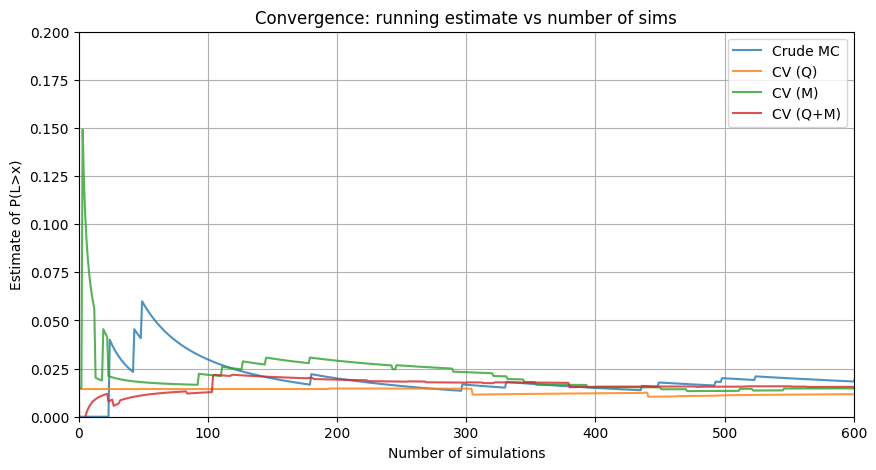

In [18]:
%matplotlib inline
m = 2
delta = np.array([2.0, 2.0])
gamma = np.identity(2)
sigma = np.array([[1.0, 0.5], [0.5, 1.0]])
x = 15.0
N = 10**6

# Crude Monte Carlo
P_crude, L = crude_monte_carlo(N, m, delta, gamma, sigma, x, loss)

# Control Variance using Q
P_cv_Q, Y_Q, Y_hat_Q = control_variance_monte_carlo(
    N, m, delta, sigma, x, Q_estimator, x/2.0)

# Control Variance using M
P_cv_M, Y_M, Y_hat_M = control_variance_monte_carlo(
    N, m, delta, sigma,  x, M_estimator, x/2.0)

# Control Variance using both Q and M
P_cv_both, Y, Y_hat_both = control_variance_both_estimators(
    N, m, delta, sigma, gamma, x, x/2.0, x/2.0)
print(f"Crude Monte Carlo estimate of P(L > {x}): {P_crude:.6f}")
print(
    f"Control Variance using Q in Monte Carlo estimate of P(L > {x}): {P_cv:.6f}")
print(f"Variance reduction: {np.var(Y_Q)/np.var(Y_hat_Q):.2f} times")
print(
    f"Control Variance using M in Monte Carlo estimate of P(L > {x}): {P_cv_M:.6f}")
print(
    f"Variance reduction: {np.var(Y_M)/np.var(Y_hat_M):.2f} times")
print(
    f"Control Variance using Q and M in Monte Carlo estimate of P(L > {x}): {P_cv_both:.6f}")
print(f"Variance reduction: {np.var(Y)/np.var(Y_hat_both):.2f} times")


y_lim = 0.2
xlim = 600

plt.figure(figsize=(10, 5))
plt.plot(running_mean((L > x)), label='Crude MC', alpha=0.8)
plt.plot(running_mean(Y_hat_Q), label='CV (Q)', alpha=0.8)
plt.plot(running_mean (Y_hat_M), label='CV (M)', alpha=0.8)
plt.plot(running_mean(Y_hat_both), label='CV (Q+M)', alpha=0.8)
plt.xlabel('Number of simulations')
plt.ylabel('Estimate of P(L>x)')
plt.title('Convergence: running estimate vs number of sims')
plt.legend()
plt.grid(True)
plt.xlim(0, xlim)
plt.ylim(0, y_lim)
plt.show()

> #### Exercise f)
> Now, use the Cholesky decomposition to find a matrix $\widetilde{C}$ such that $\Delta S=\widetilde{C} Z$ where $Z \sim N\left(0, I_2\right)$. Next, find an orthogonal matrix $U$ and a diagonal matrix $\Lambda=\operatorname{diag}\left(\lambda_1, \lambda_2\right)$ such that $\widetilde{C}^{\top} \widetilde{C}=U \Lambda U^{\top}$. Show that the loss $L$ can be expressed as $$ L=b_1 Z_1+b_2 Z_2+\lambda_1 Z_1^2+\lambda_2 Z_2^2 $$ where $b=C^{\top} \delta$ with $C=\widetilde{C} U$.

**Cholesky decomposition**

We want $\Delta S = \tilde C Z$, where $\Delta S$ follows a multivariate normal distribution. By properties of the multivariate normal distribution this is satisfied when $\Sigma_S = \tilde C I_2 \tilde{C}^{\top} = \tilde C \tilde{C}^{\top}$. This shows that the desired matrix $\tilde C$ can be obtained as the cholesky decomposistion of $\Sigma_S$, since $\Sigma_S$ has full rank. This decomposition can be found using a recursive algorithm found [here.](https://en.wikipedia.org/wiki/Cholesky_decomposition#Computation) The following shows our calculations when using the algorithm to decompose $\Sigma_S$:


$$
(i=1) \quad A^{(1)}  := \Sigma_S = \begin{pmatrix}
1 & \frac{1}{2}\\
\frac{1}{2} & 1
\end{pmatrix}
\implies  
L_1 = \begin{pmatrix}
1 & 0\\
\frac{1}{2} & 1
\end{pmatrix}
$$
$$
(i=2) \quad
A^{(2)} = \begin{pmatrix}
1 & 0\\
0 & \frac{3}{4} 
\end{pmatrix}
\implies  L_2 = \begin{pmatrix}
1 & 0\\
0 & \sqrt{\frac{3}{4} }
\end{pmatrix}
$$

$$
(i=3) \quad
A^{(3)} = \begin{pmatrix}
1 & 0\\
0 & 1
\end{pmatrix}
$$

At which point the algorithm terminates, $\tilde C$ is then obtained as follows:
$$
L_1L_2  = \begin{pmatrix}
1 & 0\\
\frac{1}{2} & 1
\end{pmatrix}\begin{pmatrix}
1 & 0\\
0 & \sqrt{\frac{3}{4} }
\end{pmatrix} = \begin{pmatrix}
1 & 0\\
\frac{1}{2} &\sqrt{\frac{3}{4} }
\end{pmatrix}:= \tilde C
$$

As a sanity check we indeed have that:
$$
\tilde C \tilde{C}^{\top } = \begin{pmatrix}
1 & \frac{1}{2}\\
\frac{1}{2} & \frac{1}{4} +\frac{3}{4} 
\end{pmatrix} = \Sigma_s
$$


**Eigen decomposition of $\tilde C$**

Note that 
$$
\tilde{C}^{\top}\tilde C  = \left(\begin{array}{ll}
\frac{5}{4}& \frac{\sqrt{3}}{4} \\
 \frac{\sqrt{3}}{4}& \frac{3}{4}
\end{array}\right)
$$ 
is a real symmetric 2x2 matrix. This implies that the Eigen decomposition $\Sigma_S = U \Lambda U^{\top}$, with $U$ orthorgonal and $\Lambda$ a diagonal matrix, has a closed form expression. i.e. for 
$$
A=\left(\begin{array}{ll}
a & b \\
b & d
\end{array}\right)
$$
the eigen values are given by  
$$
\lambda_1=\frac{a+d}{2}-\Delta, \quad \lambda_2=\frac{a+d}{2}+\Delta
$$
with
$\Delta:=\sqrt{\left(\frac{a-d}{2}\right)^2+b^2}$. For our values:
$$
\Delta = \frac{1}{2} \implies \lambda_1= \frac{1}{2}, \quad \lambda_2=\frac{3}{2}
$$

For an eigenvalue $\lambda$ a non-trivial eigenvector can be found by
$$
v_\lambda=\binom{-b}{a-\lambda},
$$
Which we can normalize to unit length:
$$
u_\lambda=\frac{v_\lambda}{\|v_{\lambda}\|}
$$
For our two eigenvalues we then get two orthonormal eigenvectors $u_1:=u_{\lambda_1}, u_2:=u_{\lambda_2}$. The matrix $U$ given by $U=\left[u_1 u_2\right]$ is then orthogonal,  we have:
$$
v_{\lambda_1}=\binom{-\frac{\sqrt{3}}{4}}{\frac{3}{4}}, 
\quad v_{\lambda_2}=\binom{-\frac{\sqrt{3}}{4}}{-\frac{1}{4}} 
\implies u_{\lambda_1} = \binom{-\frac{1}{2}}{\frac{\sqrt{3}}{2}}
\quad u_{\lambda_2} = \binom{-\frac{\sqrt{3}}{2}}{-\frac{1}{2}} 
\implies U = \begin{pmatrix}
-\frac{1}{2} & -\frac{\sqrt{3}}{2}\\
\frac{\sqrt{3}}{2} & -\frac{1}{2}
\end{pmatrix}
$$
Thus, we have arrived at our eigen decomposition:
$$
U = \begin{pmatrix}
-\frac{1}{2} & -\frac{\sqrt{3}}{2}\\
\frac{\sqrt{3}}{2} & -\frac{1}{2}
\end{pmatrix}, \quad
\Lambda = \begin{pmatrix}
\frac{1}{2} & 0\\
0 & \frac{3}{2}
\end{pmatrix}
$$


**Loss identity**

The loss is given as:
$$L=\delta^{\top} \Delta S+(\Delta S)^{\top} \Gamma \Delta S = L=\delta^{\top} \tilde C Z +(\tilde C Z)^{\top} \Gamma \tilde C Z $$
With $\Gamma = I_2$ we get:
$$
L = \delta^{\top} \tilde C Z +(\tilde C Z)^{\top} \tilde C Z = \delta^{\top} \tilde C Z +Z^{\top}(\tilde{C}^{\top} \tilde{C}) Z 
= \delta^{\top} \tilde C Z +Z^{\top}(U\Lambda U^{\top}) Z
$$
with $C = \tilde C U$ and since $U$ is orthogonal we have:
$$
L =  \delta^{\top} \tilde C Z +Z^{\top}(U\Lambda U^{\top}) Z = \delta^{\top} (\tilde C U)U^{\top}  Z +Z^{\top}(U\Lambda U^{\top}) Z = \delta^{\top} CU^{\top}  Z +Z^{\top}(U\Lambda U^{\top}) Z 
$$
with $b= \delta^{\top} C$ this becomes: 
$$
L  = b^{\top}U^{\top}  Z +Z^{\top}(U\Lambda U^{\top}) Z = b^{\top}(U^{\top}  Z) + (Z^{\top}U)\Lambda (U^{\top} Z)
$$
Now since $Z\sim N(\mathbf{0},I_2)$ and $U$ is orthogonal $U^{\top}Z = Z$ and we have:
$$
L  = b^{\top}  Z + Z\Lambda Z = b_1 Z_1 + b_2 Z_2 + \lambda_1 Z_1^2 + \lambda_2 Z_2^2
$$
Which is what we wanted to show.

> #### Exercise g)
> Similarly as in part (c), use $\prod_{i \leq 2} \exp \left(\theta_i Z_i-\psi^*\left(\theta_i\right)\right)$ as an importance-sampling density, where $\psi^*$ is the cumulant generating function of a standard normal distribution. Experiment with different parameters $\theta_i$.

We want to simulate the following using importance sampling:
$$\mathbb{P} (L > x) = \mathbb{P} (b_1 Z_1 + b_2 Z_2 + \lambda_1 Z_1 ^2 + \lambda_2 \cdot Z_2^2 > x)$$

As suggested, we use the following importance-sampling density 
$$g(z) = \prod_{i = 1}^{2} g_i (z_i) = \prod_{i = 1}^{2} \exp(\theta_i Z_i - \psi^{\ast} (\theta_i)) f(z_i)$$
Where $f(z_i)$ is the pdf of $Z_i \sim N(0,1)$ and $\psi^{\ast}$ is the cumulant generating function of a standard normal distribution, which thus is
$$\psi^{\ast} (\theta) = \log (\phi (\theta)) = \log \mathbb{E} [\exp(\theta_i Z_i)] = \frac{1}{2} \theta_i^2$$
And the weights can be computed to be
$$ W(z) = \frac{f(z)}{g(z)} = \frac{\prod_{i=1}^2 f(z_i)}{\prod_{i=1}^{2} \exp(\theta_i z_i - \psi^{\ast} (\theta_i))f(z_i)} = \prod_{i=1}^2 \exp(- \theta_i z_i + \frac{1}{2} \theta_i^2) = \exp \left( -\theta_1 z_1 - \theta_2 z_2 + \frac{\theta_1^2}{2} + \frac{\theta_2^2}{2} \right)$$

We have thus the following importance sampling method:

In [19]:
from numba import njit


@njit
def importance_sampling_estimate(Z, theta, b, lambda_, x):
    Z = Z + theta
    L_tilted = (Z@b + (Z**2)@lambda_)

    mask = L_tilted > x
    
    weights = np.exp(-(Z @ theta) + 0.5 * theta@theta)
    Y = weights * mask
    return  Y

To find the general direction of search for each $\theta$ notice that we want high values of $L$. Using the given values we compute:

In [20]:
lambda_ = np.array([0.5, 1.5])
C_tilde = np.array([[1, 0], [0.5, np.sqrt(3/4)]])
U = np.array([[-0.5, - np.sqrt(3/4)], [np.sqrt(3/4), -0.5]])

C = C_tilde @ U
b = delta.T @ C
print(f"b: ({b[0]:6f}, {b[1]:6f})")

b: (-0.000000, -3.464102)


In particular we can write:
$$
L \approx -3.464102 Z_2 + 0.5 Z_1^2 +Z_2^2 
$$
In order to promote a high likelihood of $L>x$ in our tilted distributions, we study the different terms of this approximation

**Contribution of $Z_1$**

The $Z_1$ term is $L_{Z_1}=0.5 Z_1^2$.
- This term is quadratic and symmetric around $Z_1=0$ and it is always non-negative.
- To get a large loss, we need $Z_1^2$ to be large, which means we need large values for $\left|Z_1\right|$ (i.e., $Z_1 \gg 0$ or $Z_1 \ll 0$ ).

Because the original distribution $N(0,1)$ is already centered at the point of minimum contribution ( $Z_1=0$ ), and the important regions are symmetric, shifting the mean $\theta_1$ in one direction positive or negative would miss the equally important other tail. Therefore, we expect that the best strategy for $\theta_1$ is to keep it at or near $\theta_1=0$, and rely on the variance of the standard normal distribution to generate the large positive and negative $Z_1$ values needed.

**Contribution of $Z_2$**

The $Z_2$ term is $L_{Z_2}=1.5 Z_2^2-3.464 Z_2$.
- This is a parabola, and can find its minimum by taking the derivative with respect to $Z_2$ and setting it to zero:
$$
\frac{d\left(L_{Z_2}\right)}{d Z_2}=3 Z_2-3.464=0 \Longrightarrow Z_2 \approx 1.15
$$
at this minimum, the contribution is $L_{Z_2} \approx 1.5(1.15)^2-3.464(1.15) \approx-1.99$. This means the region around $Z_2 \approx 1.15$ contributes negatively to the loss, making $L>15$ unlikely. Since the original sampling distribution $N(0,1)$ is centered at $0$, relatively close to this minimum and not in the most important region we should look for a shift.
- To get a large positive contribution from $L_{Z_2}$, we need to sample $Z_2$ values far away from the minimum at 1.15:
  * Case A (Large Positive $Z_2$ ): If $Z_2=4, L_{Z_2}=1.5(16)-3.464(4) \approx 24-13.8= 10.2$
  * Case B (Large Negative $Z_2$ ): If $Z_2=-3, L_{Z_2}=1.5(9)-3.464(-3) \approx 13.5+ 10.4=23.9$
We see that $L$ is largest in the case of a large negative shift, and we should therefore search in this region.

The above hueristics allow us to do a grid scan for some good $\theta$ parameters, this is the content of the code below.



In [ ]:
N = 10**6

theta_1s= np.linspace(-0.5,0.5,50)
theta_2s= np.linspace(-4,-1,50)

global_best_estimate = 0
global_best_thetas = (0, 0)
global_best_var = float('inf')
 
Z = np.random.normal(0, 1.0, (N,2))
for theta_1 in theta_1s:
    for theta_2 in theta_2s:
        theta = np.array([theta_1, theta_2])
        Y_IS = importance_sampling_estimate(Z, theta, b, lambda_, x)
        P_IS = np.mean(Y_IS)
        var = np.var(Y_IS, ddof=1)
        if var < global_best_var and P_IS > 0.014 and P_IS < 0.016: # to only keep reasonable estimates
            global_best_var = var
            global_best_estimate = P_IS
            global_best_thetas = theta

The result of our grid scan is the following, which indeed confirms our hueristics.

In [22]:
var_IS = global_best_var
P_IS = global_best_estimate
var_r_IS = np.var(L > x, ddof=1)/var_IS
print(f"Best thetas: {global_best_thetas}")
print(f"IS Monte Carlo estimate of P(L > {x}): {P_IS:.6f}")
print(
    f"Variance reduction factor compared to Crude MC: {var_r_IS:.2f}")

Best thetas: [ 0.01020408 -2.34693878]
IS Monte Carlo estimate of P(L > 15.0): 0.015598
Variance reduction factor compared to Crude MC: 24.41


> #### Exercise h)
> For $\left(\lambda_1 \vee \lambda_2\right) \theta<1 / 2$ show that $$\psi_L(\theta):=\log \mathbb{E}[\exp (\theta L)]=\frac{1}{2} \sum_{j \leq 2}\left(\frac{\theta^2 b_j^2}{1-2 \theta \lambda_j}-\log \left(1-2 \theta \lambda_j\right)\right) .$$ You may use without proof that $$\mathbb{E}\left[\exp \left(\theta\left(Z_1+c\right)^2\right)\right]=(1-2 \theta)^{-1 / 2} \exp \left(\theta c^2 /(1-2 \theta)\right)$$ holds for all $c \in \mathbb{R}$ and $\theta<1 / 2$.

Using exercise f) we have:
$$
\log \mathbb{E}[\exp (\theta L)]=\log \mathbb{E}[\exp(\theta (b_1 Z_1 + b_2 Z_2 + \lambda_1 Z_1^2 + \lambda_2 Z_2^2))] =
\prod_{i=1}^2 \mathbb{E}[\exp(\theta(b_i Z_i + \lambda_i Z_i^2))]
$$
where we used that $Z_1$ is independent of $Z_2$, through properties of the multivariate normal distribution. We consider one of these expectations:
$$
\mathbb{E}[\exp(\theta(b_i Z_i + \lambda_i Z_i^2))] = \mathbb{E}\left[\exp\left(\theta\lambda_i\left(\frac{b_i}{\lambda_i} Z_i +  Z_i^2\right)\right)\right]
$$
where we assume that $\lambda_i \neq 0$ (which is the case for the given parameters). Completing the square gives:
$$
\mathbb{E}[\exp(\theta(b_i Z_i + \lambda_i Z_i^2))] 
= \mathbb{E}\left[\exp\left(\theta\lambda_i\left(\frac{b_i}{2\lambda_i}  +  Z_i\right)^2 - \frac{\theta b_i^{2} }{4\lambda_i}\right) \right] 
= \mathbb{E}\left[\exp\left(\theta\lambda_i\left(\frac{b_i}{2\lambda_i}  +  Z_i\right)^2 \right) \right] \exp\left(- \frac{\theta b_i^{2} }{4\lambda_i}\right)
$$



The given identity then applies and we have:
$$
\mathbb{E}[\exp(\theta(b_i Z_i + \lambda_i Z_i^2))] = \exp\left(- \frac{\theta b_i^{2} }{4\lambda_i}\right) \left(1-2 \theta \lambda_i\right)^{-1 / 2} \exp \left(\frac{\theta \lambda_i \cdot\left(b_j /\left(2 \lambda_i\right)\right)^2}{1-2 \theta \lambda_i}\right)
= \exp\left(- \frac{\theta b_i^{2} }{4\lambda_i}\right) \left(1-2 \theta \lambda_i\right)^{-1 / 2} \exp \left(\frac{\theta b_i^2}{4 \lambda_i} \cdot \frac{1}{1-2 \theta \lambda_i}\right)
$$


Combining and rewriting gives:
$$
\mathbb{E}[\exp(\theta(b_i Z_i + \lambda_i Z_i^2))]=\left(1-2 \theta \lambda_j\right)^{-1 / 2} \exp \left(\frac{\theta^2 b_i^2}{2\left(1-2 \theta \lambda_i\right)}\right) 
$$
All in all:
$$
\mathbb{E}\left[e^{\theta L}\right]=\prod_{j=1}^2\left(1-2 \theta \lambda_i\right)^{-1 / 2} \exp \left(\frac{\theta^2 b_i^2}{2\left(1-2 \theta \lambda_i\right)}\right) 
$$
Taking logarithms gives the cumulant-generating function
$$
\psi_L(\theta):=\log \mathbb{E}\left[e^{\theta L}\right]=\sum_{i=1}^2\left[\frac{\theta^2 b_i^2}{2\left(1-2 \theta \lambda_j\right)}-\frac{1}{2} \log \left(1-2 \theta \lambda_i\right)\right] 
$$
Or, equivalently,
$$
\psi_L(\theta)=\frac{1}{2} \sum_{i \leq 2}\left(\frac{\theta^2 b_i^2}{1-2 \theta \lambda_i}-\log \left(1-2 \theta \lambda_i\right)\right)
$$
Which exactly holds for all $\theta$ with $\left(\lambda_1 \vee \lambda_2\right) \theta<\frac{1}{2}$, since this implies that  $1-2 \theta \lambda_i>0$.

> #### Exercise i)
> Use part (h) to develop an importance-sampling algorithm for the estimation of $\mathbb{P}(L>15)$. Develop a heuristic for choosing $\theta$.

From exercise (h) we have, that if we let $\theta \in \left( 0, \frac{1}{2 \max{\lambda_1, \lambda_2}} \right)$, then 
$$\psi_L (\theta) = \frac{1}{2} \sum_{j=1}^{2} \left( \frac{\theta^2 b_j^2}{1 - 2\theta \lambda_j} - \log (1 - 2\theta \lambda_j)\right)$$
Thus, it makes sense to let $f_Q$ be
$$f_Q (l) = \frac{\exp{\theta l}}{\mathbb{E} [\exp{\theta L}]} f_P (l) = \frac{\exp{\theta l}}{\exp{\psi_L (\theta)}} f_P (l) = \exp{(\theta l - \psi_L (\theta))} f_P (l)$$
Giving the following weight:
$$\frac{f_P (z)}{f_Q(z)} = \frac{f_P (z)}{\exp{(\theta z - \psi_L (\theta))} f_P (z)} = \exp{(\psi_L (\theta) - \theta z)}$$
Therefore, we will simulate $\mathbb{P} (L > 15)$ by simulating $L$ under the distribution $f_Q$ and afterwards correcting to the computed weights, as:
$$\mathbb{P} (L > 15) = \mathbb{E} [1_{L > 15} \cdot f_P (L)] = \mathbb{E} \left[ 1_{L > 15} \cdot f_Q (L) \frac{f_P (L)}{ f_Q (L)} \right]$$

But in order to simulate $L$ under the distribution $f_Q$ we need to find the optimal $\theta$, i.e. $\theta^{\ast}$ fulfilling:
$$\psi^{\prime} (\theta^{\ast}) = 15$$
We start by computing $\psi^{\prime} (\theta)$:
$$\psi_L^{\prime}(\theta) = \frac{1}{2} \sum_{j=1}^2 \left( \frac{2\theta b_j^2 (1 - 2\theta \lambda_j) - \theta^2 b_j^2 (-2 \lambda_j)}{(1 - 2\theta \lambda_j)^2} - \frac{-2 \lambda_j}{1 - 2\theta \lambda_j} \right)$$
$$ = \frac{1}{2} \sum_{j=1}^2 \left( \frac{2\theta b_j^2 - 4\theta^2 b_j^2 \lambda_j + 2\theta^2 b_j^2 \lambda_j}{(1 - 2\theta \lambda_j)^2} + \frac{2 \lambda_j}{1 - 2\theta \lambda_j} \right)$$
$$ = \sum_{j=1}^2 \left( \frac{\theta b_j^2 (1 - \theta \lambda_j)}{(1 - 2\theta \lambda_j)^2} + \frac{\lambda_j}{1 - 2\theta \lambda_j} \right)$$
But $\psi^{\prime} (\theta^{\ast}) = 15$ can't be solved analytically, which means that we need to solve it algorithmically. We will return to this part.

When $\theta^{\ast}$ is found algorithmically, $L$ can be simulated by:
$$L_{tilted} = b_1 Z_1^{tilted} + b_2 Z_2^{tilted} + \lambda_1 (Z_1^{tilted})^2 + \lambda_2 (Z_2^{tilted})^2$$
Where
$$Z_i^{tilted} \sim N(\mu_j^{tilted}, (\sigma_j^{tilted})^2)$$
$$\mu_j^{tilted} = \frac{\theta^{\ast} b_j}{ 1 - 2\theta^{\ast}}, \qquad (\sigma_j^{tilted})^2 = \frac{1}{1 - 2\theta^{\ast} \lambda_j}$$
This is a result of the following:

From earlier we had
$$f_Q(z_1, z_2) = \exp{(\theta^{\ast} L(z_1, z_2) - \psi_L (\theta^{\ast}))} f_P(z_1, z_2)$$
Using that $Z_1$ and $Z_2$ are independent and the definition of $L$ and $\psi_L$, gives
$$f_Q(z_1, z_2) = \exp{(\theta^{\ast} L_1 + \theta^{\ast} L_2  - \psi_{L_1} (\theta^{\ast}) - \psi_{L_2} (\theta^{\ast}))} f_{Z_1}(z_1) f_{Z_2}(z_2)$$
Where $L_j = b_j Z_j + \lambda_j Z_j^2$ for $j=1, 2$. We can further rewrite
$$ = \prod_{j=1}^2 \left( \exp{( \theta^{\ast} L_j (z_j) - \psi_{L_j} (\theta^{\ast}))} f_{Z_j} (z_j) \right)$$
And we therefore have that $Z_1$ and $Z_2$ are independent as well under $Q$.

Now let's finally compute the distribution of $Z_j$ under $Q$. From before we have the following distribution of $Z_j$ under Q:
$$f_Q^{j} (z_j) = \exp{( \theta^{\ast} L_j (z_j) - \psi_{L_j} (\theta^{\ast}))} f_{Z_j} (z_j)$$
We use that $L_j = b_j Z_j + \lambda_j Z_j^2$ and that $Z_j \sim N(0,1)$:
$$= \exp{( \theta^{\ast} (b_j Z_j + \lambda_j Z_j^2) - \psi_{L_j} (\theta^{\ast}))} \frac{1}{\sqrt{2\pi}} \exp{- \frac{1}{2} z_j^2}$$
$$= \frac{1}{\sqrt{2\pi}} \exp{\left( \theta^{\ast} (b_j Z_j + \lambda_j Z_j^2) - \psi_{L_j} (\theta^{\ast}) - \frac{1}{2} z_j^2 \right)}$$
$$= \frac{1}{\sqrt{2\pi}} \exp{\left( - \frac{1}{2} z_j^2 (1 - 2\theta^{\ast} \lambda_j) + \theta^{\ast} b_j z_j - \psi_{L_j} (\theta^{\ast})\right) }$$

If we now let $z_j \sim N(\mu_j, \sigma_j^2)$ where $\mu_j = \frac{\theta^{\ast} b_j}{ 1 - 2\theta^{\ast}}, \; \sigma_j^2 = \frac{1}{1 - 2\theta^{\ast} \lambda_j}$, then
$$f_Q^{j} (z_j) = \frac{1}{\sqrt{2\pi}} \exp{\left( - \frac{1}{2} z_j^2 \frac{1}{\sigma_j^2} + \frac{\mu_j}{\sigma_j^2} z_j - \psi_{L_j} (\theta^{\ast})\right) }$$
Which is exactly the pdf of a normal distribution.


Thus, in conclusion $L$ can be simulated by:

* Compute the optimal $\theta$ by solving $\psi^{\prime} (\theta^{\ast}) = 15$ with a heuristic.

* Simulate $Z_1$ and $Z_2$ where $Z_j \sim N(\mu_j^{tilted}, (\sigma_j^{tilted})^2)$, where $\mu_j^{tilted}, (\sigma_j^{tilted})^2$ are given as
    $$\mu_j^{tilted} = \frac{\theta^{\ast} b_j}{ 1 - 2\theta^{\ast}}, \qquad (\sigma_j^{tilted})^2 = \frac{1}{1 - 2\theta^{\ast} \lambda_j}$$

* Compute $L_{tilted}$ as
    $$L_{tilted} = b_1 Z_1^{tilted} + b_2 Z_2^{tilted} + \lambda_1 (Z_1^{tilted})^2 + \lambda_2 (Z_2^{tilted})^2$$

* Determine $\hat{p}$ as
    $$\hat{p} = \mathbb{E}_Q \left[ 1_{L_{tilted} > 15} \frac{f_P (z)}{f_Q(z)} \right]$$
    Where $\frac{f_P (z)}{f_Q(z)} = \exp{(\psi_L (\theta^{\ast}) - \theta z)}$, and $\psi_L (\theta^{\ast})$ can be found above.


Now it is only left to develop a heuristic for choosing $\theta^{\ast}$:

We start by noticing that as $\psi^{\prime}$ is a third-degree polynomium, then it has at max 2 local extremes. Furthermore, since $\theta \in \left( 0, \frac{1}{2 \max{\lambda_1, \lambda_2}} \right)$ then we have a bounded interval to check $\theta$ for.

We'll start by discretizing the interval 

In [23]:
theta_min = 0
theta_max = 1 / (2 * np.max(lambda_)) 

thetas = np.linspace(theta_min, theta_max, 40)

> #### Exercise j)
> Describe broadly how stratified sampling could be used for simulating $L$ when the random variable $Q$ is used for stratification. For this question, a description of your approach is sufficient; you do not need to implement a simulation program.

Stratified sampling is a variance reduction technique in Monte Carlo simulation. Instead of drawing all samples from the full distribution, we:

1. Partition the sample space of a random variable into disjoint regions.  
2. Sample separately within each stratum, ensuring that every region is represented.  
3. Weight results by the probability of each stratum to form an unbiased overall estimator.

This main idea is then that this reduces the variance because variation within each stratum is typically smaller than for the full population. The method is particularly good if the strata are chosen based on a variable correlated with the output of interest. To implement this method using $Q$ as the random variable we could do as follows.

1. First we partition the range of $Q$ into intervals $S_1, \dots, S_K$. To do this let $\sigma_Q^2=\delta^{\top} \Sigma_S \delta$ and choose boundaries $-\infty=a_0<a_1<\cdots<a_K=\infty$. Then $S_k= \left\{a_{k-1} \leq Q<a_k\right\}.$


2. Then we compute all the stratum probabilities: 
$$
p_k=\mathbb{P}\left(S_k\right)=\Phi\left(\frac{a_k}{\sigma_Q}\right)-\Phi\left(\frac{a_{k-1}}{\sigma_Q}\right)
$$
   where $Q \sim N(0, \delta^T \Sigma_S \delta)$.
  We can then allocate sample sizes of each stratum proportional to the probability mass contained within it, i.e. $n_k = N\cdot p_k$. Then we sample within each strata as follows: 
   - Draw samples from the conditional distribution of $\Delta S$ given $Q \in S_k$, i.e. $\Delta S | Q \in S_k$
   - Compute the loss within the strata $L_{k}$.
3. The Stratified sampling estimator, can then be obtained through the weights: 
  $$
   \hat{\mathbb{P}}(L>x) = \sum_{k=1}^K p_k 
   \left( \frac{1}{n_k} \sum_{i=1}^{n_k} \mathbf{1}_{L_{k}>x} \right)
   $$


The rationale behind the above would then be that 

- $L$ is positively correlated with $Q \implies$ stratifying on $Q$ should give smaller sample variation.  
- Concentrating samples on the tail where $Q > x$ occurs should further reduce the estimator variance.  
